In [12]:
!pip install gymnasium pygame -q
!git clone https://github.com/MattChanTK/gym-maze.git
!cd gym-maze && python3 setup.py install

fatal: destination path 'gym-maze' already exists and is not an empty directory.
Python 


In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import gymnasium as gym

import warnings

import matplotlib.animation as animation
from IPython.display import HTML

In [2]:
gym.__version__

'1.3.0'

In [3]:
def get_epsilon_greedy_action(q_values, epsilon, action_n):
    policy = np.ones(action_n) * epsilon / action_n
    max_action = np.argmax(q_values)
    policy[max_action] += 1 - epsilon

    return np.random.choice(np.arange(action_n), p=policy)

In [4]:
def QLearning(env, episode_n, noisy_episode_n, gamma=0.99, t_max=500, alpha=0.5):
    state_n = env.observation_space.n  # Получаем количество состояний в среде
    action_n = env.action_space.n  # Получаем количество действий в среде

    Q = np.zeros((state_n, action_n))  # Создаем Q-функцию (матрицу состояние-действие) и инициализируем её нулями
    epsilon = 1  # Инициализируем действием рандомный шанс

    total_rewards = []  # Создаем массив для хранения общих вознаграждений для каждого эпизода
    for episode in range(episode_n):  # Запускаем цикл для каждого эпизода

        total_reward = 0  # Инициализируем общую сумму вознаграждений для каждого эпизода
        state, _ = env.reset()  # Инициализируем состояние и действие в среде

        for t in range(t_max):  # Запускаем цикл для каждого шага в эпизоде

            # Делаем действие с рандомным шансом epsilon

            action = get_epsilon_greedy_action(Q[state], epsilon, action_n)  # Делаем действие с шансом epsilo
            next_state, reward, done, _, _ = env.step(action)  # Делаем шаг в среде и получаем результат

            Q[state][action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state][action])  # Обновляем Q-функцию

            total_reward += reward  # Добавляем вознаграждение к общей сумме вознаграждений для эпизода

            if done:  # Если эпизод завершён, то выходим из цикла
                break

            state = next_state  # Обновляем состояние в среде

        epsilon = max(0, epsilon - 1 / noisy_episode_n)  # Обновляем действием шанс

        total_rewards.append(total_reward)  # Добавляем вознаграждение к общей сумме вознаграждений для эпизода
        
    return total_rewards, Q  # Возвращаем общие вознаграждения для каждого эпизода

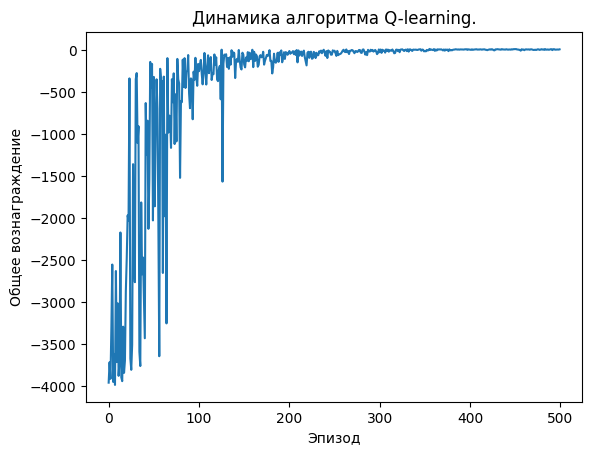

In [5]:
env = gym.make("Taxi-v4", render_mode="rgb_array")

total_rewards, Q = QLearning(env, episode_n=500, noisy_episode_n=400, t_max=1000, gamma=0.999, alpha=0.5)

plt.plot(total_rewards)
plt.title('Динамика алгоритма Q-learning.')
plt.xlabel('Эпизод')
plt.ylabel('Общее вознаграждение')
plt.show()

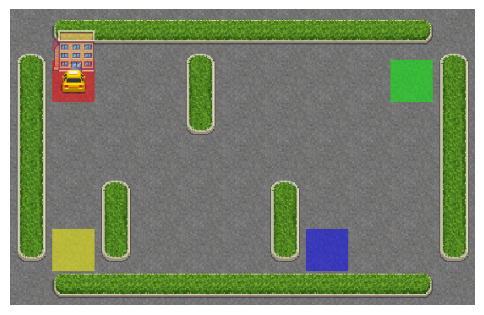

In [7]:
t_max = 1000
action_n = env.action_space.n  

# Собираем кадры за один эпизод
frames = []

state, info = env.reset()
frames.append(env.render())

for t in range(t_max):  # Запускаем цикл для каждого шага в эпизоде
    action = Q[state].argmax()
    next_state, reward, done, _, _ = env.step(action)  # Делаем шаг в среде и получаем результат
    frames.append(env.render())

    if done:  # Если эпизод завершён, то выходим из цикла
        break
    state = next_state  # Обновляем состояние в среде

# Настройка фигуры matplotlib для анимации
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')
patch = ax.imshow(frames[0])

def update(i):
    patch.set_data(frames[i])
    return [patch]

anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=500, blit=True)

# Для отображения в Jupyter Notebook
HTML(anim.to_jshtml())
